6장 자연어 처리

# 예제 6.1

https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt

https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

In [ ]:
# 예제 6.1 감성 분석 양방향 LSTM 모델(한글 NSMC 데이터셋)

from google.colab import drive
drive.mount("/content/drive")

In [ ]:
# KoNLPy 설치
!pip install konlpy

In [ ]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dense
from tensorflow.keras.layers import Embedding, TextVectorization
from konlpy.tag import Okt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 데이터셋 준비
train_path = "/content/drive/MyDrive/Datasets/nsmc_small/train.csv"
train_df = pd.read_csv(train_path)

test_path = "//content/drive/MyDrive/Datasets/nsmc_small/test.csv"
test_df = pd.read_csv(test_path)

print(train_df.shape)   # 학습 데이터 shape 확인
print(test_df.shape)   # 테스트 데이터 shape 확인

(15000, 3)
(2500, 3)


In [ ]:
# 상위 데이터 확인
train_df.head(10)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,9008700,걍인피니트가짱이다.진짜짱이다♥,1
2,4581211,나름 심오한 뜻도 있는 듯. 그냥 학생이 선생과 놀아나는 영화는 절대 아님,1
3,6331922,엄포스의 위력을 다시 한번 깨닫게 해준 적.남 꽃검사님도 연기 정말 좋았어요! 완전...,1
4,9336496,단순하면서 은은한 매력의 영화,1
5,9063648,영화가 사람의 영혼을 어루만져 줄 수도 있군요 거친 세상사를 잠시 잊고 동화같은 영...,1
6,1031725,보는내내 그대로 들어맞는 예측 카리스마 없는 악역,0
7,2192046,아 일본영화 다이런건가?? 유치하다,0
8,2009382,뭐냐..시작하고 3분만에 나왔다. 리플릿 사진 보며 불안하더니만..,0
9,7852366,성룡영화중 최악인듯 ㅋㅋ,0


In [ ]:
# 텍스트 정제
train_df["document"] = train_df["document"].str.replace(
    "[^A-Za-z가-힣]", " ", regex=True)

# 토큰화
okt = Okt()   # 한글 형태소 분석기 지정

stop_words = ["가", "을", "은", "과", "의", "도",   # 불용어 지정
              "이", "를", "는", "와", "에", "들"]

def tokenize(text):   # 토큰화 함수 정의
    tokens = okt.morphs(text)
    return [token for token in tokens if token not in stop_words]

train_df["document"] = train_df["document"].apply(lambda x: ' '.join(tokenize(x)))

In [ ]:
# 텍스트 벡터화
vocab_size = 20000   # 어휘 사전 크기
sequence_length = 50   # 시퀀스 길이

vectorizer = TextVectorization(max_tokens=vocab_size,
                               standardize="lower_and_strip_punctuation",
                               split="whitespace",
                               output_mode="int",   # 정수 출력
                               output_sequence_length=sequence_length)

vectorizer.adapt(train_df["document"])   # 어휘 사전 생성

In [ ]:
# 학습/검증 데이터 분할
train_size = int(0.8 * len(train_ds))

x_train = train_ds[:train_size]
x_valid = train_ds[train_size:]

y_train = train_df["label"][:train_size]
y_valid = train_df["label"][train_size:]

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_valid.shape, y_valid.shape)   # 검증 데이터 shape 확인

(12000, 50) (12000,)
(3000, 50) (3000,)


In [ ]:
# 모델 생성
inputs = Input(shape=(None,))
x = Embedding(vocab_size, 128)(inputs)   # 임베딩 차원 128
x = Bidirectional(LSTM(16, return_sequences=True))(x)
x = Bidirectional(LSTM(16))(x)
outputs = Dense(1, activation="sigmoid")(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=3,
                    validation_data=(x_valid, y_valid))

Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6307 - loss: 0.6128 - val_accuracy: 0.8083 - val_loss: 0.4218
Epoch 2/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9055 - loss: 0.2604 - val_accuracy: 0.7997 - val_loss: 0.4457
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9584 - loss: 0.1319 - val_accuracy: 0.8010 - val_loss: 0.5444


In [ ]:
# 모델 평가
test_ds = test_df["document"].str.replace(
    "[^A-Za-z가-힣]", " ", regex=True)   # 텍스트 정제
test_ds = test_ds.apply(lambda x: " ".join(tokenize(x)))   # 토큰화
test_ds = vectorizer(test_ds)   # 텍스트 벡터화

model.evaluate(test_ds, test_df["label"])

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7771 - loss: 0.6017


[0.6171132326126099, 0.7815999984741211]

In [ ]:
# 모델 예측
prediction = model.predict(test_ds)
predict = (prediction >= 0.5).astype(int)   # 임계치 0.5

for i in range(3):
    print(f"document: {test_df['document'][i]}")
    print(f"label: {test_df['label'][i]}")
    print(f"predict: {predict[i].item()} \n")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
document: 굳 ㅋ
label: 1
predict: 1 

document: '13일의 금요일', '나이트메어'시리즈와 함께 가장 많은 시리즈를 양산해냈던 헬레이저 시리즈의 첫편. 작가의 상상력이 돋보이는 작품이며, 갈고리로 사지찢는 고어씬은 지금보더라도 상당히 잔인하고 충격적이다.
label: 1
predict: 0 

document: EBS 한국영화특선 해서 봤다.Biff 개막작 선정되서 왤까 궁금 했었는데 봐도 이율 모르겠다...
label: 0
predict: 0 



#예제 6.2

https://www.manythings.org/anki/

In [ ]:
# 예제 6.2 Seq2Seq 모델 기계 번역(영어-한글)

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout
from tensorflow.keras.layers import Attention, Concatenate, TextVectorization
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import random
import string
import re

In [ ]:
# 데이터셋 준비
file_path = "/content/drive/MyDrive/Datasets/anki_kor-eng/kor.txt"   # 경로 지정

with open(file_path, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

print(f"number of lines: {len(lines)}")   # 라인 수 확인

number of lines: 6381


In [ ]:
# 텍스트 쌍 생성
text_pair = []

for line in lines:
    input_text, target_text, _ = line.split("\t")
    target_text = "[start] " + target_text + " [end]"   # 시작/끝 추가
    text_pair.append((input_text, target_text))

print(f"text pair: {text_pair[0]}")   # 텍스트 쌍 확인

text pair: ('Go.', '[start] 가. [end]')


In [ ]:
# 학습/테스트 데이터 분할
train_pair, test_pair = train_test_split(
    text_pair, test_size=0.1, random_state=77)   # 분할 비율 0.1

train_input = [pair[0] for pair in train_pair]   # 학습 데이터(입력)
train_target = [pair[1] for pair in train_pair]   # 학습 데이터 (정답)

test_input = [pair[0] for pair in test_pair]   # 테스트 데이터(입력)
test_target = [pair[1] for pair in test_pair]   # 테스트 데이터(정답)

In [ ]:
# 표준화 함수 정의
def standardization(input_string):
    new_punctuation = re.sub(r"[\[\]]", " ", string.punctuation)   # 구두점에서 [ 와 ] 제외
    pattern = f"[{re.escape(new_punctuation)}]"   # 구두점을 정규식 패턴으로 변환
    return tf.strings.regex_replace(input_string, pattern, " ")   # 정규식 패턴을 ""으로 대체

In [ ]:
# 텍스트 벡터화
vocab_size = 7000   # 어휘 사전 크기
sequence_length = 10   # 시퀀스 길이

source_vectorizer = TextVectorization(   # 입력 텍스트 벡터화
    max_tokens=vocab_size,
    standardize="lower_and_strip_punctuation",
    output_mode="int",   # 정수 출력
    output_sequence_length=sequence_length)

target_vectorizer = TextVectorization(   # 정답 텍스트 벡터화
    max_tokens=vocab_size,
    standardize=standardization,
    output_mode="int",   # 정수 출력
    output_sequence_length=sequence_length +1)

source_vectorizer.adapt(train_input)   # 어휘 사전 생성
target_vectorizer.adapt(train_target)

In [ ]:
# 학습 데이터 쌍 생성
x_train_encoder = source_vectorizer(train_input)
x_train_decoder = target_vectorizer(train_target)[:, :-1]   # [end] 제외
y_train = target_vectorizer(train_target)[:, 1:]   # [start] 제외

In [ ]:
# 모델 생성
embedding_dim = 512
units = 1024

encoder_inputs = Input(shape=(None,), name="encoder")
x = Embedding(vocab_size, embedding_dim)(encoder_inputs)
encoder_lstm = LSTM(units, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(x)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(None,), name="decoder")
x = Embedding(vocab_size, embedding_dim)(decoder_inputs)
decoder_lstm = LSTM(units, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(x, initial_state=encoder_states)

x = Attention(name="attention")([decoder_outputs, encoder_outputs])   # 문맥 벡터
x = Concatenate(axis=-1)([decoder_outputs, x])
x = Dense(units, activation="tanh")(x)   # 어텐션 벡터
x = Dropout(0.5)(x)
outputs = Dense(vocab_size, activation="softmax", name="output")(x)

model = Model([encoder_inputs, decoder_inputs], outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
# 모델 학습
history = model.fit([x_train_encoder, x_train_decoder], y_train,
                    verbose=0, epochs=10,
                    validation_split=0.1)   # 분할 비율 0.1

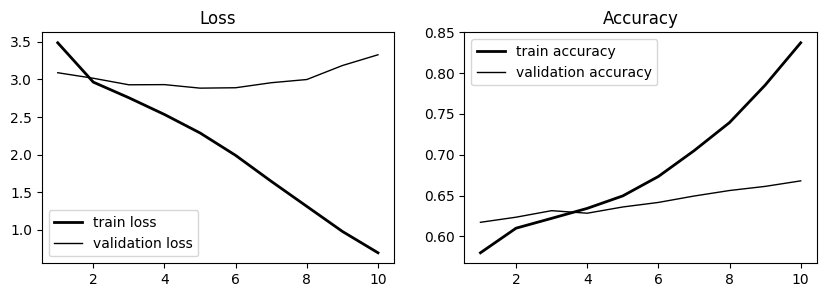

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history.history["loss"]) + 1),
         history.history["loss"], label="train loss",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_loss"]) + 1),
         history.history["val_loss"], label="validation loss",
         color="black", linewidth=1)
plt.title("Loss")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history.history["accuracy"]) + 1),
         history.history["accuracy"], label="train accuracy",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_accuracy"]) + 1),
         history.history["val_accuracy"], label="validation accuracy",
         color="black", linewidth=1)
plt.title("Accuracy")
plt.legend(loc="best")

plt.show()

In [ ]:
# 번역 함수 정의
def translate(input_sentence):
    input_text = source_vectorizer([input_sentence])

    results = "[start]"   # 시작 토큰

    for i in range(sequence_length):
        target_text = target_vectorizer([results])   # 토큰화
        predictions = model.predict([input_text, target_text], verbose=0)   # 예측
        token_index = np.argmax(predictions[0, i, :])
        outputs = target_vectorizer.get_vocabulary()[token_index]
        results += " " + outputs

        if outputs == "[end]":   # 종료 토큰
            break
    return results

In [ ]:
# 번역
sentence = test_pair[5]

print(f"test input: {sentence[0]}")
print(f"target: {sentence[1]}")
print(f"translation: {translate(sentence[0])} \n")

test input: I did my best.
target: [start] 그게 내 최선이었어. [end]
translation: [start] 최선을 다하겠습니다 [end] 



In [ ]:
# 예제 6.3 트랜스포머를 이용한 문장 생성

# 허깅페이스 트랜스포머 설치
!pip install transformers

In [ ]:
# 문장 생성 파이프라인
from transformers import pipeline

generator = pipeline("text-generation",
                     model="skt/kogpt2-base-v2",
                     tokenizer="skt/kogpt2-base-v2")

In [ ]:
# 문장 생성
prompt = "오늘 날씨가 정말"   # 시작 문장

generated_text = generator(prompt,
                           max_new_tokens=50,   # 생성할 단어 수
                           temperature=0.7)   # 소프트맥스 온도

print(generated_text)

[{'generated_text': '오늘 날씨가 정말 좋습니다\n네~ 이렇게 날씨에 대해서 자세하게 알아봤습니다.\n자~ 첫 번째 사진부터 보시죠.\n네. 봄이 왔음을 알리는 벚꽃 사진입니다.\n봄을 알리는 벚꽃 사진들이 봄을 알리는 벚꽃 사진으로 변신했'}]
